# 🏡 Dự Đoán Giá Nhà (House Prices Advanced Regression Techniques)
## So Sánh 6 Mô Hình Machine Learning: LightGBM, XGBoost, CatBoost, Random Forest, Ridge, ElasticNet

Dự án này triển khai toàn diện quy trình Data Science chuẩn mực cho bài toán hồi quy định giá bất động sản (Ames Housing Dataset), bao gồm:
1. **Tiền xử lý dữ liệu chuẩn xác**:
   - Loại bỏ đúng 2 outlier theo khuyến nghị chính thức: `GrLivArea > 4000 & SalePrice < 300000`.
   - Điền NaN có ý nghĩa $\rightarrow$ `"None"` (thuộc tính vắng mặt) và `0` (diện tích/số lượng không tồn tại).
   - Điền `LotFrontage` theo **median theo phân vùng Neighborhood**.
   - Điền các NaN còn lại theo **mode** (biến phân loại) và **median** (biến số học).
   - Biến đổi log biến mục tiêu: $y = \ln(1 + \text{SalePrice})$.
   - Loại bỏ đặc trưng gần như hằng số (**Near-Zero Variance** $>99\%$ đồng nhất).
   - Mã hóa One-Hot Encoding cho các biến phân loại, kèm chuẩn hóa `StandardScaler` cho Ridge & ElasticNet.
2. **Huấn luyện & Đánh giá 6 Mô hình qua 5-Fold Cross Validation**:
   - **LightGBM**, **XGBoost**, **CatBoost**, **Random Forest**, **Ridge**, **ElasticNet**.
3. **Phân tích Chuyên sâu & 7 Biểu đồ Trực quan hóa**:
   - **1. Bảng tổng hợp metric**: CV RMSE (mean ± std), MAE, R², thời gian train, sai số đô-la thực tế.
   - **2. Bar chart so sánh RMSE giữa các model** (kèm error bar).
   - **3. Heatmap tương quan giữa các dự đoán** (OOF predictions).
   - **4. Scatter Actual vs Predicted** (lưới 2x3 kèm đường lý tưởng $y=x$).
   - **5. Residual plot** (lưới 2x3 kiểm tra phương sai đồng nhất).
   - **6. Feature Importance so sánh 4 model cây** (Top 15 đặc trưng chuẩn hóa %).
   - **7. Box plot phân phối RMSE qua các fold CV** (đánh giá tính ổn định).
4. **Dự đoán Test Set & Mô hình Ensemble tối ưu**.


In [ ]:
# Thiết lập thư viện và cấu hình hiển thị
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Cấu hình đồ thị và cảnh báo
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.autolayout'] = True
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Đã tải đầy đủ các thư viện Machine Learning!")


Đã tải đầy đủ các thư viện Machine Learning!


---
## 1. Tải Dữ Liệu & Khám Phá Ban Đầu
Tải tập dữ liệu huấn luyện (`train.csv`) và tập dữ liệu kiểm thử (`test.csv`).


In [ ]:
# Đọc dữ liệu từ thư mục chứa dataset
train_path = os.path.join('house-prices-advanced-regression-techniques', 'train.csv')
test_path = os.path.join('house-prices-advanced-regression-techniques', 'test.csv')

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(f"Kích thước tập Train ban đầu: {train.shape}")
print(f"Kích thước tập Test ban đầu : {test.shape}")
train.head(3)


Kích thước tập Train ban đầu: (1460, 81)
Kích thước tập Test ban đầu : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0000,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0000,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


---
## 2. Tiền Xử Lý Dữ Liệu

### 2.1 Loại bỏ Outlier theo khuyến nghị của tác giả Ames Housing
Dean De Cock (tác giả tập dữ liệu) chỉ ra có 2 ngôi nhà có diện tích sinh hoạt cực lớn (`GrLivArea > 4000`) nhưng giá bán lại bất thường rất thấp (`SalePrice < 300000`), làm sai lệch nghiêm trọng các thuật toán hồi quy.


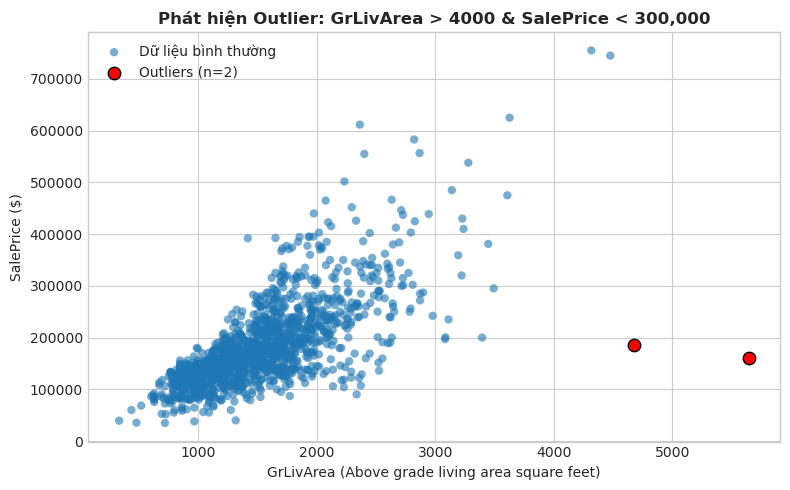

-> Danh sách các ID outlier bị loại bỏ: [524, 1299]
-> Kích thước tập Train sau khi loại bỏ outlier: (1458, 81)


In [ ]:
# Kiểm tra và trực quan hóa Outliers trước khi lọc
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.6, edgecolors='none', color='#1f77b4', label='Dữ liệu bình thường')

outlier_cond = (train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)
outliers = train[outlier_cond]
ax.scatter(outliers['GrLivArea'], outliers['SalePrice'], color='red', s=80, edgecolors='black', label=f'Outliers (n={len(outliers)})')

ax.set_title('Phát hiện Outlier: GrLivArea > 4000 & SalePrice < 300,000', fontsize=12, fontweight='bold')
ax.set_xlabel('GrLivArea (Above grade living area square feet)')
ax.set_ylabel('SalePrice ($)')
ax.legend()
plt.show()

print(f"-> Danh sách các ID outlier bị loại bỏ: {outliers['Id'].tolist()}")
train = train[~outlier_cond].reset_index(drop=True)
print(f"-> Kích thước tập Train sau khi loại bỏ outlier: {train.shape}")


### 2.2 Biến đổi Log (Log-Transformation) Biến Mục Tiêu `SalePrice`
Phân phối giá nhà thường bị lệch phải (right-skewed). Việc áp dụng phép biến đổi $y = \ln(1 + \text{SalePrice})$ giúp đưa biến mục tiêu về dạng phân phối chuẩn, hạn chế tác động của giá nhà quá đắt lên hàm tổn thất RMSE.


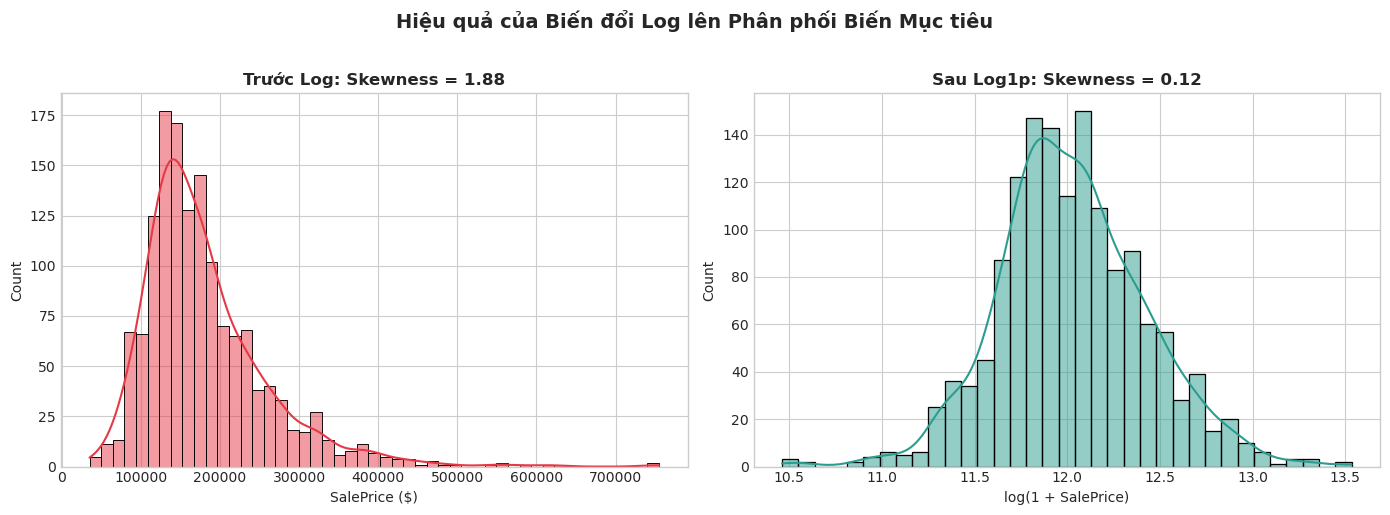

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Trước biến đổi
sns.histplot(train['SalePrice'], kde=True, ax=ax1, color='#e63946')
ax1.set_title(f'Trước Log: Skewness = {train["SalePrice"].skew():.2f}', fontweight='bold')
ax1.set_xlabel('SalePrice ($)')

# Log-transform
y_train = np.log1p(train['SalePrice']).values
train_ids = train['Id'].values
test_ids = test['Id'].values

train_features = train.drop(columns=['Id', 'SalePrice'])
test_features = test.drop(columns=['Id'])

n_train = len(train_features)
all_data = pd.concat([train_features, test_features], ignore_index=True)

# Sau biến đổi
sns.histplot(y_train, kde=True, ax=ax2, color='#2a9d8f')
ax2.set_title(f'Sau Log1p: Skewness = {pd.Series(y_train).skew():.2f}', fontweight='bold')
ax2.set_xlabel('log(1 + SalePrice)')

plt.suptitle('Hiệu quả của Biến đổi Log lên Phân phối Biến Mục tiêu', fontsize=14, fontweight='bold', y=1.02)
plt.show()


### 2.3 Xử lý Giá Trị Thiếu (NaN) Có Ý Nghĩa
Trong tập Ames Housing, `NA` ở nhiều cột không phải là mất dữ liệu ngẫu nhiên mà đại diện cho việc **không có tiện ích đó**:
- Thuộc tính phân loại: Hồ bơi (`PoolQC`), Lối đi sau (`Alley`), Hàng rào (`Fence`), Lò sưởi (`FireplaceQu`), Gara (`GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`), Tầng hầm (`BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`), Ốp tường (`MasVnrType`) $\rightarrow$ Điền `"None"`.
- Thuộc tính định lượng: Diện tích/Số lượng gara, diện tích tầng hầm, phòng tắm tầng hầm, diện tích ốp tường $\rightarrow$ Điền `0`.


In [ ]:
# Điền "None" cho các thuộc tính phân loại
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtQual', 'BsmtCond',
    'MasVnrType'
]
for col in none_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

# Điền 0 cho các thuộc tính định lượng
zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in zero_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

print(f"-> Đã điền 'None' cho {len(none_cols)} cột phân loại và 0 cho {len(zero_cols)} cột định lượng có ý nghĩa.")


-> Đã điền 'None' cho 15 cột phân loại và 0 cho 10 cột định lượng có ý nghĩa.


### 2.4 Điền `LotFrontage` theo Median Nhóm `Neighborhood` và các NaN còn lại
Chiều dài mặt tiền đường (`LotFrontage`) của một ngôi nhà có tương quan mật thiết với quy hoạch của khu phố (`Neighborhood`) mà ngôi nhà đó tọa lạc. Vì vậy, ta nhóm theo từng khu phố để lấy median điền vào.
Các cột còn lại được điền bằng:
- Biến phân loại: `mode` (giá trị phổ biến nhất).
- Biến định lượng: `median`.


In [ ]:
# Điền LotFrontage theo Neighborhood
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
all_data['LotFrontage'] = all_data['LotFrontage'].fillna(all_data['LotFrontage'].median())

# Điền các NaN còn lại
num_cols = all_data.select_dtypes(include=[np.number]).columns
cat_cols = all_data.select_dtypes(include=['object', 'category', 'string']).columns

for col in num_cols:
    if all_data[col].isnull().any():
        all_data[col] = all_data[col].fillna(all_data[col].median())

for col in cat_cols:
    if all_data[col].isnull().any():
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print(f"Kiểm tra tổng số NaN còn lại trong toàn bộ tập dữ liệu: {all_data.isnull().sum().sum()}")


Kiểm tra tổng số NaN còn lại trong toàn bộ tập dữ liệu: 0


### 2.5 Loại Bỏ Biến Gần Như Hằng Số (Near-Zero Variance) & Mã Hóa One-Hot
Các cột có hơn $99\%$ giá trị đồng nhất (như `Street`, `Utilities`, `Condition2`) hầu như không mang thông tin phân biệt mà chỉ làm tăng chiều dữ liệu gây quá khớp (overfitting).
Sau đó, các biến phân loại được mã hóa One-Hot Encoding (`pd.get_dummies`). Tên cột được làm sạch để tương thích tuyệt đối với LightGBM và XGBoost.


In [ ]:
# Chuyển các cột số mang bản chất phân loại về kiểu chuỗi
str_cols = ['MSSubClass', 'MoSold', 'YrSold']
for col in str_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].astype(str)

# Kiểm tra và loại bỏ cột Near-zero variance trên tập Train
train_subset = all_data.iloc[:n_train]
nzv_cols = []
for col in all_data.columns:
    top_freq = train_subset[col].value_counts(normalize=True).iloc[0]
    if top_freq >= 0.99:
        nzv_cols.append(col)

print(f"-> Các cột Near-zero variance (>99% giá trị giống nhau) bị loại bỏ: {nzv_cols}")
all_data = all_data.drop(columns=nzv_cols)

# One-Hot Encoding
all_data_encoded = pd.get_dummies(all_data, drop_first=True)

# Làm sạch tên cột (tránh lỗi ký tự [, ], < trong LightGBM/XGBoost)
all_data_encoded.columns = [re.sub(r'[\[\]<, ]', '_', c) for c in all_data_encoded.columns]

X_train = all_data_encoded.iloc[:n_train].copy()
X_test = all_data_encoded.iloc[n_train:].copy()
feature_names = all_data_encoded.columns.tolist()

print(f"Kích thước X_train sau tiền xử lý: {X_train.shape}")
print(f"Kích thước X_test sau tiền xử lý : {X_test.shape}")


-> Các cột Near-zero variance (>99% giá trị giống nhau) bị loại bỏ: ['Street', 'Utilities', 'Condition2', 'PoolArea', 'PoolQC']
Kích thước X_train sau tiền xử lý: (1458, 272)
Kích thước X_test sau tiền xử lý : (1459, 272)


---
## 3. Khởi Tạo 6 Mô Hình Machine Learning

Các mô hình được lựa chọn đại diện cho các trường phái thuật toán tiêu biểu:
1. **LightGBM**: Mô hình Gradient Boosting dựa trên cấu trúc cây phân nhánh theo lá (leaf-wise), huấn luyện siêu tốc và chính xác cao.
2. **XGBoost**: Thuật toán Extreme Gradient Boosting với kiểm soát điều chuẩn chính quy L1/L2 mạnh mẽ.
3. **CatBoost**: Gradient Boosting tối ưu cho bài toán dữ liệu bảng phân loại với cơ chế Ordered Boosting chống rò rỉ thông tin.
4. **Random Forest**: Mô hình Bagging cổ điển với hàng trăm cây quyết định độc lập, có tính ổn định cao.
5. **Ridge Regression**: Hồi quy tuyến tính có điều chuẩn phạt $L_2$ (Tikhonov Regularization), kết hợp với `StandardScaler`.
6. **ElasticNet**: Kết hợp điều chuẩn cả $L_1$ (Lasso) và $L_2$ (Ridge), kết hợp với `StandardScaler`.


In [ ]:
models = {
    'LightGBM': LGBMRegressor(
        n_estimators=850,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=850,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),
    'CatBoost': CatBoostRegressor(
        iterations=950,
        learning_rate=0.03,
        depth=5,
        random_state=42,
        verbose=0
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=15.0, random_state=42))
    ]),
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.005, l1_ratio=0.5, random_state=42, max_iter=3000))
    ])
}

print(f"Đã cấu hình thành công 6 mô hình: {list(models.keys())}")


Đã cấu hình thành công 6 mô hình: ['LightGBM', 'XGBoost', 'CatBoost', 'Random Forest', 'Ridge', 'ElasticNet']


---
## 4. Huấn Luyện & Đánh Giá 5-Fold Cross Validation
Áp dụng `KFold(n_splits=5, shuffle=True, random_state=42)` để đánh giá công bằng, thu thập dự đoán Out-Of-Fold (OOF) và đo lường thời gian huấn luyện.


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
X_mat = X_train.values

results = []
oof_predictions = {}
cv_fold_rmse = {}
fitted_models = {}
tree_importances = {}

print("Bắt đầu huấn luyện 5-Fold Cross Validation trên cả 6 mô hình...")
print("-" * 75)

for name, model in models.items():
    t0 = time.time()
    oof_pred = np.zeros(len(y_train))
    fold_rmses = []
    fold_models = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_mat, y_train)):
        X_tr, y_tr = X_mat[train_idx], y_train[train_idx]
        X_va, y_va = X_mat[val_idx], y_train[val_idx]

        model.fit(X_tr, y_tr)
        val_pred = model.predict(X_va)
        oof_pred[val_idx] = val_pred

        fold_rmse = np.sqrt(mean_squared_error(y_va, val_pred))
        fold_rmses.append(fold_rmse)
        fold_models.append(model)

    train_time = time.time() - t0
    oof_predictions[name] = oof_pred
    cv_fold_rmse[name] = fold_rmses
    fitted_models[name] = fold_models

    mean_rmse = np.mean(fold_rmses)
    std_rmse = np.std(fold_rmses)
    mae = mean_absolute_error(y_train, oof_pred)
    r2 = r2_score(y_train, oof_pred)

    # Đổi về thang đo USD thực tế
    y_real = np.expm1(y_train)
    pred_real = np.expm1(oof_pred)
    rmse_dollars = np.sqrt(mean_squared_error(y_real, pred_real))
    mae_dollars = mean_absolute_error(y_real, pred_real)

    print(f"{name:15s} | CV RMSE: {mean_rmse:.4f} (±{std_rmse:.4f}) | MAE: {mae:.4f} | R²: {r2:.4f} | Time: {train_time:.2f}s")

    results.append({
        'Model': name,
        'CV RMSE Mean': mean_rmse,
        'CV RMSE Std': std_rmse,
        'CV RMSE (mean ± std)': f"{mean_rmse:.4f} ± {std_rmse:.4f}",
        'CV MAE': mae,
        'CV R²': r2,
        'Train Time (s)': round(train_time, 2),
        'RMSE ($)': round(rmse_dollars, 2),
        'MAE ($)': round(mae_dollars, 2)
    })

results_df = pd.DataFrame(results).sort_values(by='CV RMSE Mean', ascending=True).reset_index(drop=True)
oof_df = pd.DataFrame(oof_predictions)
cv_fold_rmse_df = pd.DataFrame(cv_fold_rmse)

# Trích xuất Feature Importance cho 4 mô hình cây
print("")
print("Trích xuất Feature Importance cho 4 mô hình cây...")
for tree_name in ['LightGBM', 'XGBoost', 'CatBoost', 'Random Forest']:
    m = models[tree_name]
    m.fit(X_mat, y_train)
    if hasattr(m, 'feature_importances_'):
        imp = m.feature_importances_
    elif hasattr(m, 'get_feature_importance'):
        imp = m.get_feature_importance()
    else:
        imp = np.zeros(X_mat.shape[1])
    imp_norm = (imp / np.sum(imp)) * 100
    tree_importances[tree_name] = imp_norm
print("Hoàn tất huấn luyện!")


Bắt đầu huấn luyện 5-Fold Cross Validation trên cả 6 mô hình...
---------------------------------------------------------------------------


LightGBM        | CV RMSE: 0.1224 (±0.0091) | MAE: 0.0845 | R²: 0.9056 | Time: 2.66s


XGBoost         | CV RMSE: 0.1193 (±0.0098) | MAE: 0.0820 | R²: 0.9103 | Time: 4.16s


CatBoost        | CV RMSE: 0.1171 (±0.0092) | MAE: 0.0803 | R²: 0.9136 | Time: 14.19s


Random Forest   | CV RMSE: 0.1422 (±0.0100) | MAE: 0.0955 | R²: 0.8728 | Time: 1.83s
Ridge           | CV RMSE: 0.1305 (±0.0152) | MAE: 0.0878 | R²: 0.8918 | Time: 0.16s


ElasticNet      | CV RMSE: 0.1177 (±0.0091) | MAE: 0.0814 | R²: 0.9128 | Time: 0.22s

Trích xuất Feature Importance cho 4 mô hình cây...


Hoàn tất huấn luyện!


---
## 5. Báo Cáo & 7 Biểu Đồ Trực Quan Hóa Chuyên Sâu

### 1. Bảng tổng hợp metric (Quan trọng nhất)
Bảng tổng hợp xếp hạng các mô hình dựa trên độ chính xác CV RMSE, kèm theo độ lệch chuẩn qua các fold, hệ số xác định $R^2$, thời gian huấn luyện và sai số thực tế tính bằng USD.


In [ ]:
# Hiển thị bảng tổng hợp metric
display_table = results_df[[
    'Model', 'CV RMSE (mean ± std)', 'CV MAE', 'CV R²',
    'Train Time (s)', 'RMSE ($)', 'MAE ($)'
]]

# Định dạng bảng nổi bật với gradient
styled_table = display_table.style.format({
    'CV MAE': '{:.4f}',
    'CV R²': '{:.4f}',
    'Train Time (s)': '{:.2f}s',
    'RMSE ($)': '${:,.2f}',
    'MAE ($)': '${:,.2f}'
}).background_gradient(subset=['CV MAE'], cmap='YlGn_r') \
  .background_gradient(subset=['CV R²'], cmap='YlGn') \
  .set_caption("BẢNG TỔNG HỢP SO SÁNH 6 MÔ HÌNH MACHINE LEARNING (5-FOLD CV)")

styled_table


,Model,CV RMSE (mean ± std),CV MAE,CV R²,Train Time (s),RMSE ($),MAE ($)
0,CatBoost,0.1171 ± 0.0092,0.0803,0.9136,14.19s,"$22,380.25","$14,202.01"
1,ElasticNet,0.1177 ± 0.0091,0.0814,0.9128,0.22s,"$21,006.91","$14,004.85"
2,XGBoost,0.1193 ± 0.0098,0.0820,0.9103,4.16s,"$22,447.22","$14,454.40"
3,LightGBM,0.1224 ± 0.0091,0.0845,0.9056,2.66s,"$23,534.93","$15,007.83"
4,Ridge,0.1305 ± 0.0152,0.0878,0.8918,0.16s,"$23,095.46","$14,949.99"
5,Random Forest,0.1422 ± 0.0100,0.0955,0.8728,1.83s,"$30,386.02","$17,467.12"


### 2. Bar Chart So Sánh RMSE Giữa Các Model
Trực quan hóa trực tiếp giá trị Mean CV RMSE và thanh sai số ($\pm$ độ lệch chuẩn std), giúp xác định ngay mô hình đạt hiệu năng tốt nhất.


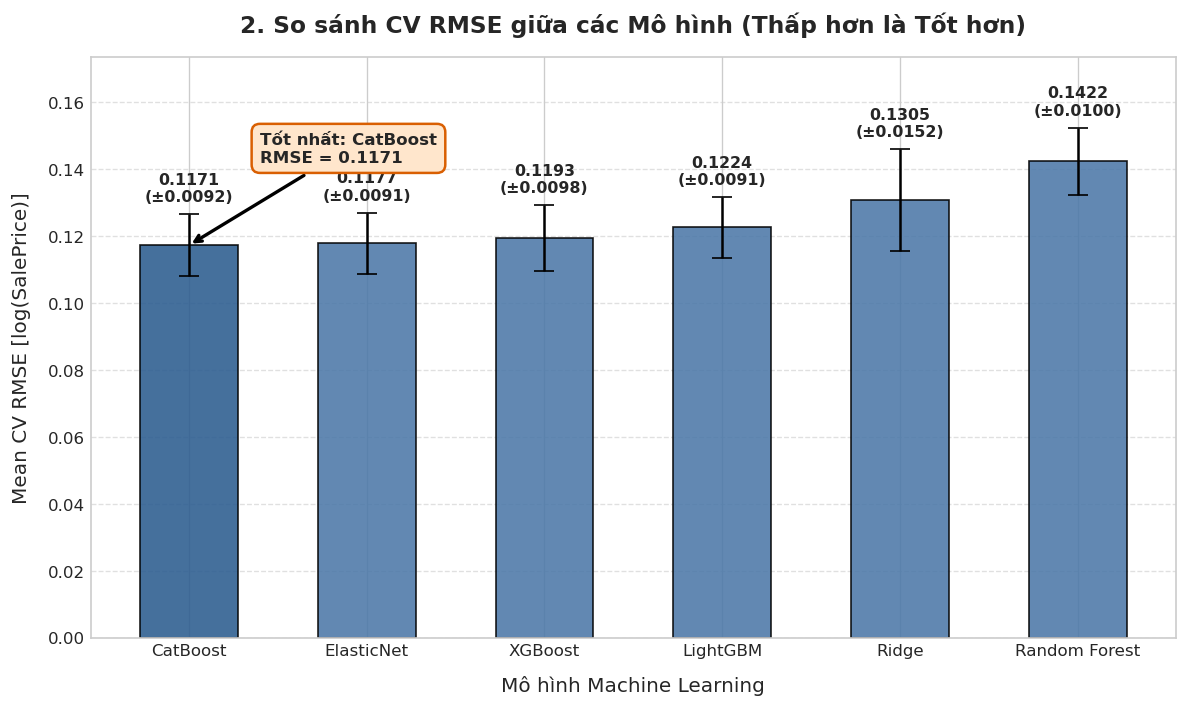

In [ ]:
plt.figure(figsize=(10, 6), dpi=120)
sorted_df = results_df.sort_values(by='CV RMSE Mean', ascending=True)

colors = ['#2b5c8f' if i == 0 else '#4c78a8' for i in range(len(sorted_df))]
bars = plt.bar(
    sorted_df['Model'],
    sorted_df['CV RMSE Mean'],
    yerr=sorted_df['CV RMSE Std'],
    capsize=6,
    color=colors,
    edgecolor='black',
    alpha=0.88,
    width=0.55
)

best_model = sorted_df.iloc[0]['Model']
best_rmse = sorted_df.iloc[0]['CV RMSE Mean']

plt.title('2. So sánh CV RMSE giữa các Mô hình (Thấp hơn là Tốt hơn)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mô hình Machine Learning', fontsize=12, labelpad=10)
plt.ylabel('Mean CV RMSE [log(SalePrice)]', fontsize=12, labelpad=10)
plt.ylim(0, max(sorted_df['CV RMSE Mean']) * 1.22)

for bar, (_, row) in zip(bars, sorted_df.iterrows()):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.,
        height + row['CV RMSE Std'] + 0.003,
        f"{row['CV RMSE Mean']:.4f}\n(±{row['CV RMSE Std']:.4f})",
        ha='center', va='bottom', fontsize=9.5, fontweight='bold'
    )

plt.annotate(
    f'Tốt nhất: {best_model}\nRMSE = {best_rmse:.4f}',
    xy=(0, best_rmse),
    xytext=(0.4, best_rmse + 0.025),
    arrowprops=dict(facecolor='#d95f02', arrowstyle='->', lw=2),
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffe6cc', edgecolor='#d95f02', lw=1.5),
    fontweight='bold', fontsize=10
)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### 3. Heatmap Tương Quan Giữa Các Dự Đoán Của Model
Phân tích ma trận tương quan Pearson giữa Out-Of-Fold (OOF) predictions của 6 mô hình.
- Nếu các mô hình có độ tương quan thấp hơn (ví dụ mô hình Tuyến tính vs Mô hình Cây), việc kết hợp chúng (**Ensemble / Blending**) sẽ triệt tiêu sai số và mang lại hiệu năng cao hơn đáng kể.


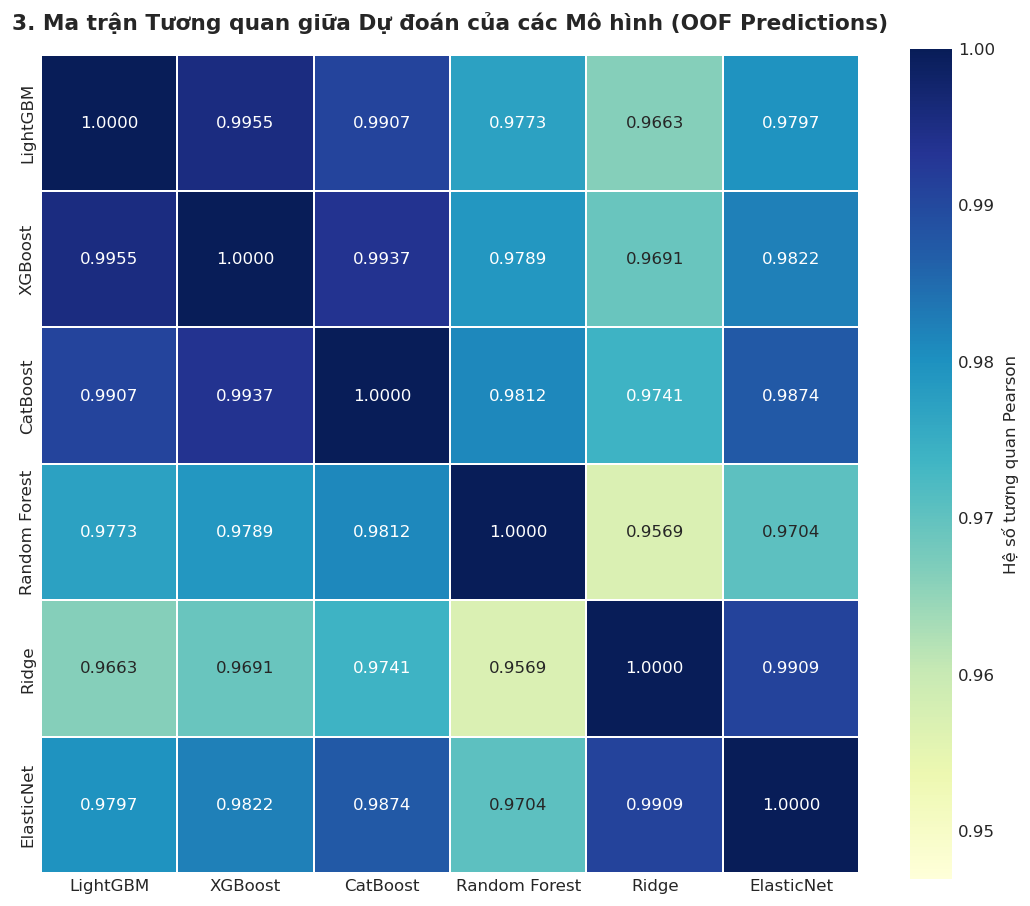

In [ ]:
plt.figure(figsize=(9, 7.5), dpi=120)
corr = oof_df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".4f",
    cmap='YlGnBu',
    vmin=corr.min().min() - 0.01,
    vmax=1.0,
    square=True,
    linewidths=1.2,
    linecolor='white',
    cbar_kws={'label': 'Hệ số tương quan Pearson'}
)

plt.title('3. Ma trận Tương quan giữa Dự đoán của các Mô hình (OOF Predictions)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### 4. Scatter Actual vs Predicted (Dạng Lưới 2x3)
Kiểm tra xem các mô hình có xảy ra sai lệch hệ thống (systematic bias) hay không, đặc biệt là ở phân khúc nhà giá rẻ (bị ước lượng quá cao) hoặc phân khúc biệt thự đắt tiền (bị ước lượng quá thấp).


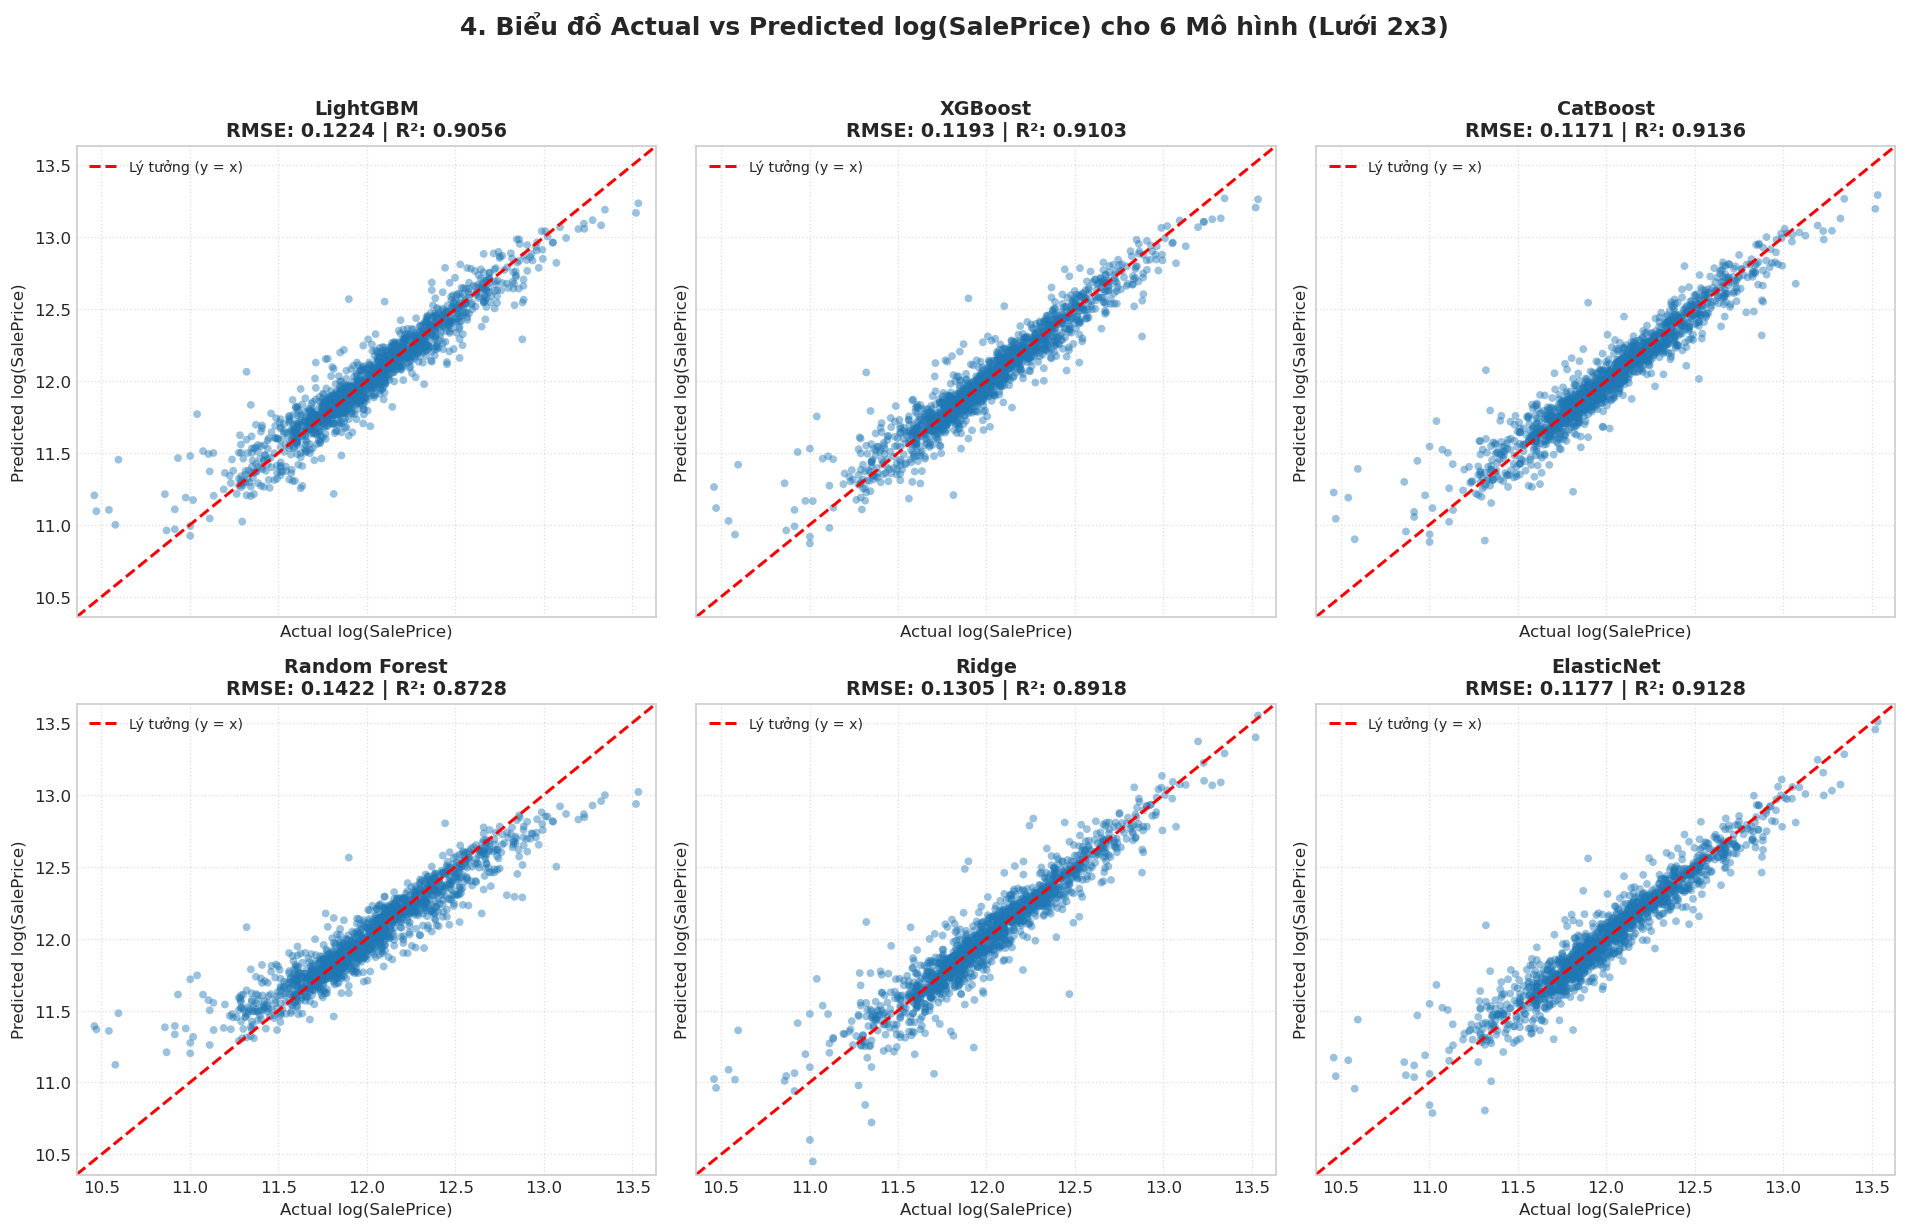

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=120, sharex=True, sharey=True)
axes = axes.flatten()

y_min, y_max = y_train.min() - 0.1, y_train.max() + 0.1
models_list = list(oof_df.columns)

for i, name in enumerate(models_list):
    ax = axes[i]
    pred = oof_df[name]

    model_row = results_df[results_df['Model'] == name].iloc[0]
    rmse = model_row['CV RMSE Mean']
    r2 = model_row['CV R²']

    ax.scatter(y_train, pred, alpha=0.45, color='#1f77b4', edgecolors='none', s=22)
    ax.plot([y_min, y_max], [y_min, y_max], 'r--', lw=1.8, label='Lý tưởng (y = x)')

    ax.set_title(f"{name}\nRMSE: {rmse:.4f} | R²: {r2:.4f}", fontsize=11.5, fontweight='bold')
    ax.set_xlabel('Actual log(SalePrice)', fontsize=10)
    ax.set_ylabel('Predicted log(SalePrice)', fontsize=10)
    ax.set_xlim(y_min, y_max)
    ax.set_ylim(y_min, y_max)
    ax.legend(loc='upper left', fontsize=8.5)
    ax.grid(True, linestyle=':', alpha=0.6)

fig.suptitle('4. Biểu đồ Actual vs Predicted log(SalePrice) cho 6 Mô hình (Lưới 2x3)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 5. Residual Plot (Dạng Lưới 2x3)
Kiểm tra tính đồng nhất của phương sai phần dư (**Homoscedasticity**) bằng biểu đồ Residuals $(y - \hat{y})$ theo giá trị dự đoán $\hat{y}$.
- Nếu phần dư phân bố ngẫu nhiên xung quanh đường $0$ trong dải $\pm 2\sigma$, mô hình thỏa mãn giả định hồi quy tốt.


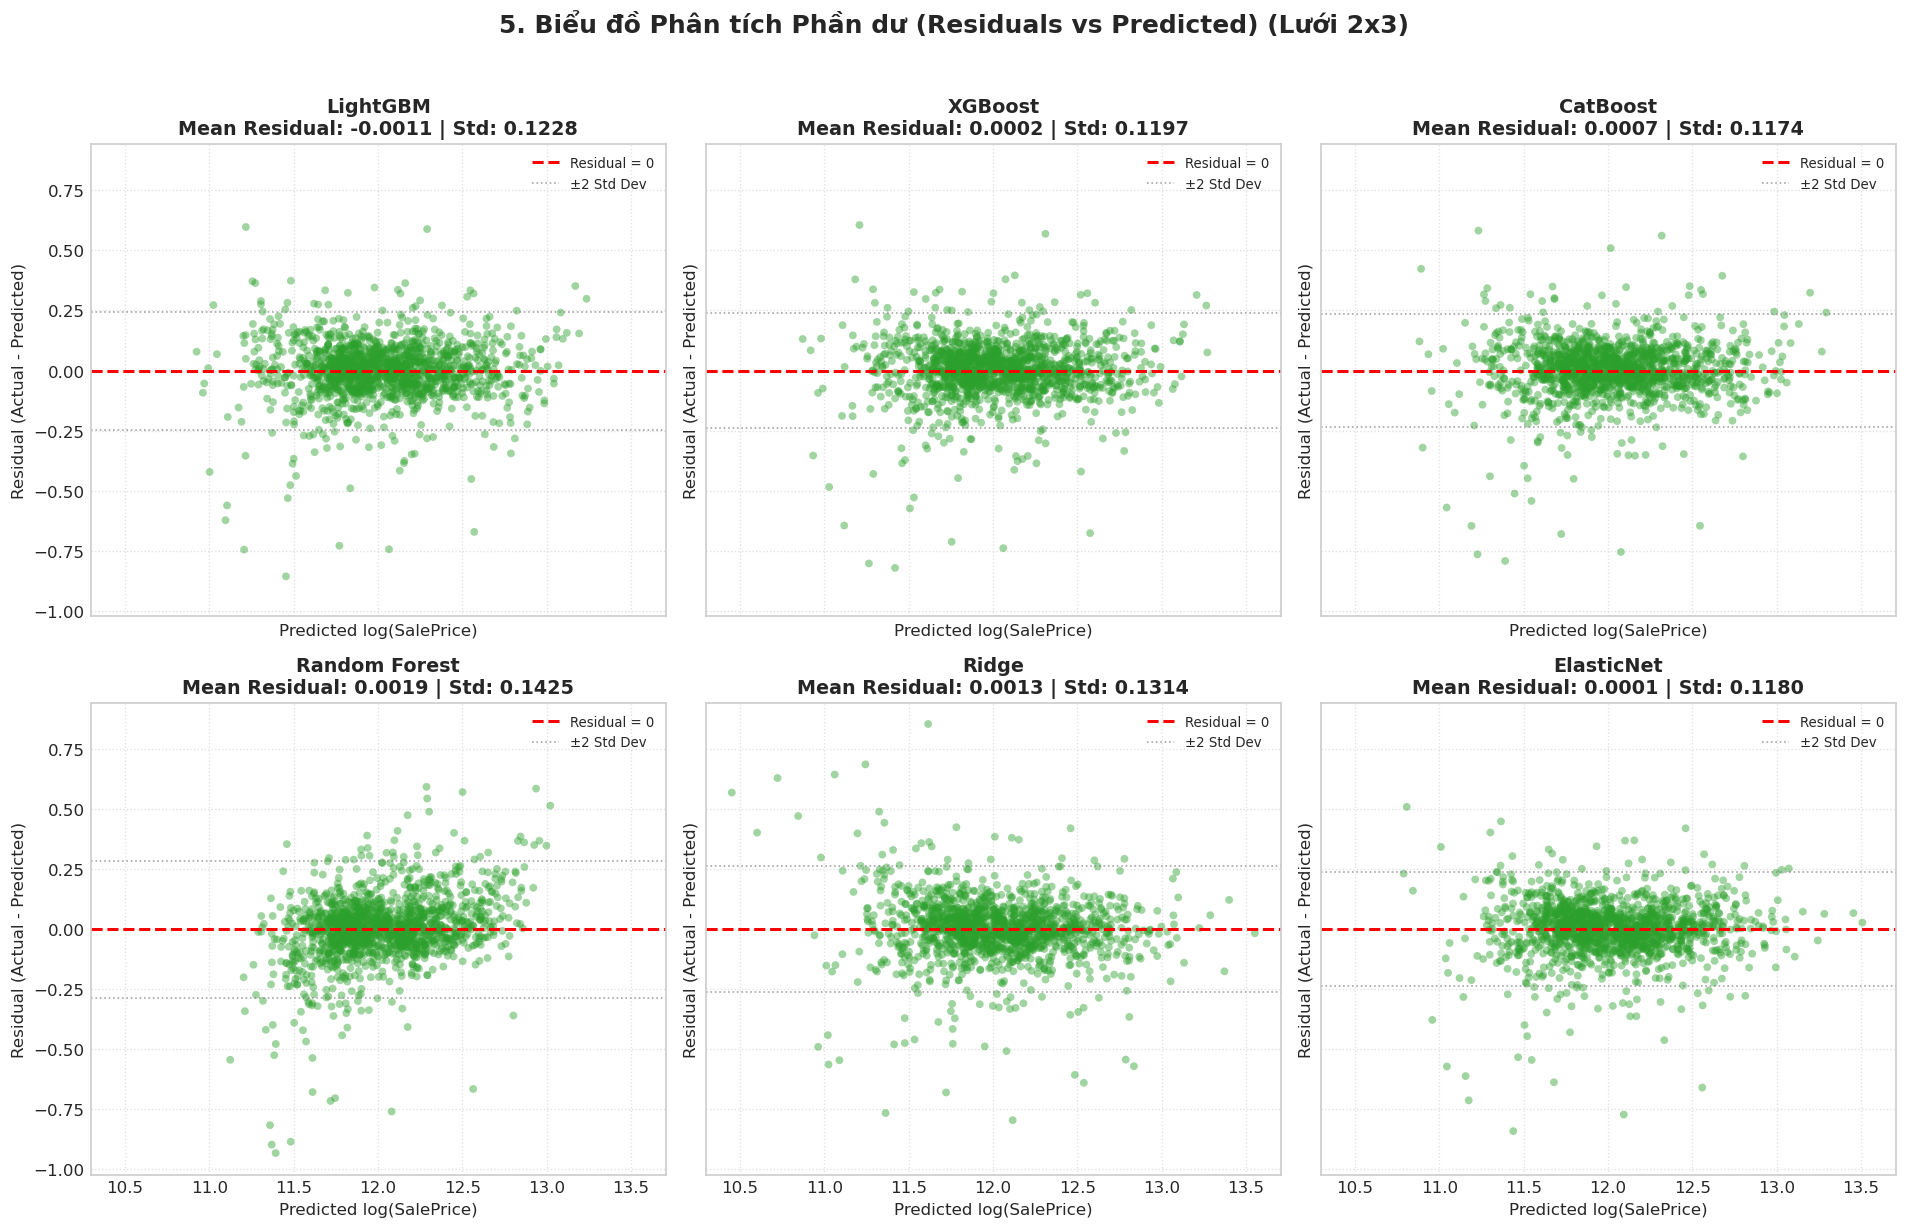

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=120, sharex=True, sharey=True)
axes = axes.flatten()

for i, name in enumerate(models_list):
    ax = axes[i]
    pred = oof_df[name]
    residuals = y_train - pred

    ax.scatter(pred, residuals, alpha=0.45, color='#2ca02c', edgecolors='none', s=22)
    ax.axhline(0, color='red', linestyle='--', lw=1.8, label='Residual = 0')

    res_std = np.std(residuals)
    ax.axhline(2 * res_std, color='gray', linestyle=':', lw=1, alpha=0.7, label='±2 Std Dev')
    ax.axhline(-2 * res_std, color='gray', linestyle=':', lw=1, alpha=0.7)

    ax.set_title(f"{name}\nMean Residual: {residuals.mean():.4f} | Std: {res_std:.4f}", fontsize=11.5, fontweight='bold')
    ax.set_xlabel('Predicted log(SalePrice)', fontsize=10)
    ax.set_ylabel('Residual (Actual - Predicted)', fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.6)

fig.suptitle('5. Biểu đồ Phân tích Phần dư (Residuals vs Predicted) (Lưới 2x3)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 6. So Sánh Feature Importance Giữa 4 Mô Hình Cây
So sánh top 15 đặc trưng quan trọng nhất giữa **LightGBM**, **XGBoost**, **CatBoost**, và **Random Forest**.
Độ quan trọng của từng mô hình được chuẩn hóa thành tỷ lệ phần trăm ($\%$) để đảm bảo so sánh khách quan và đồng nhất.


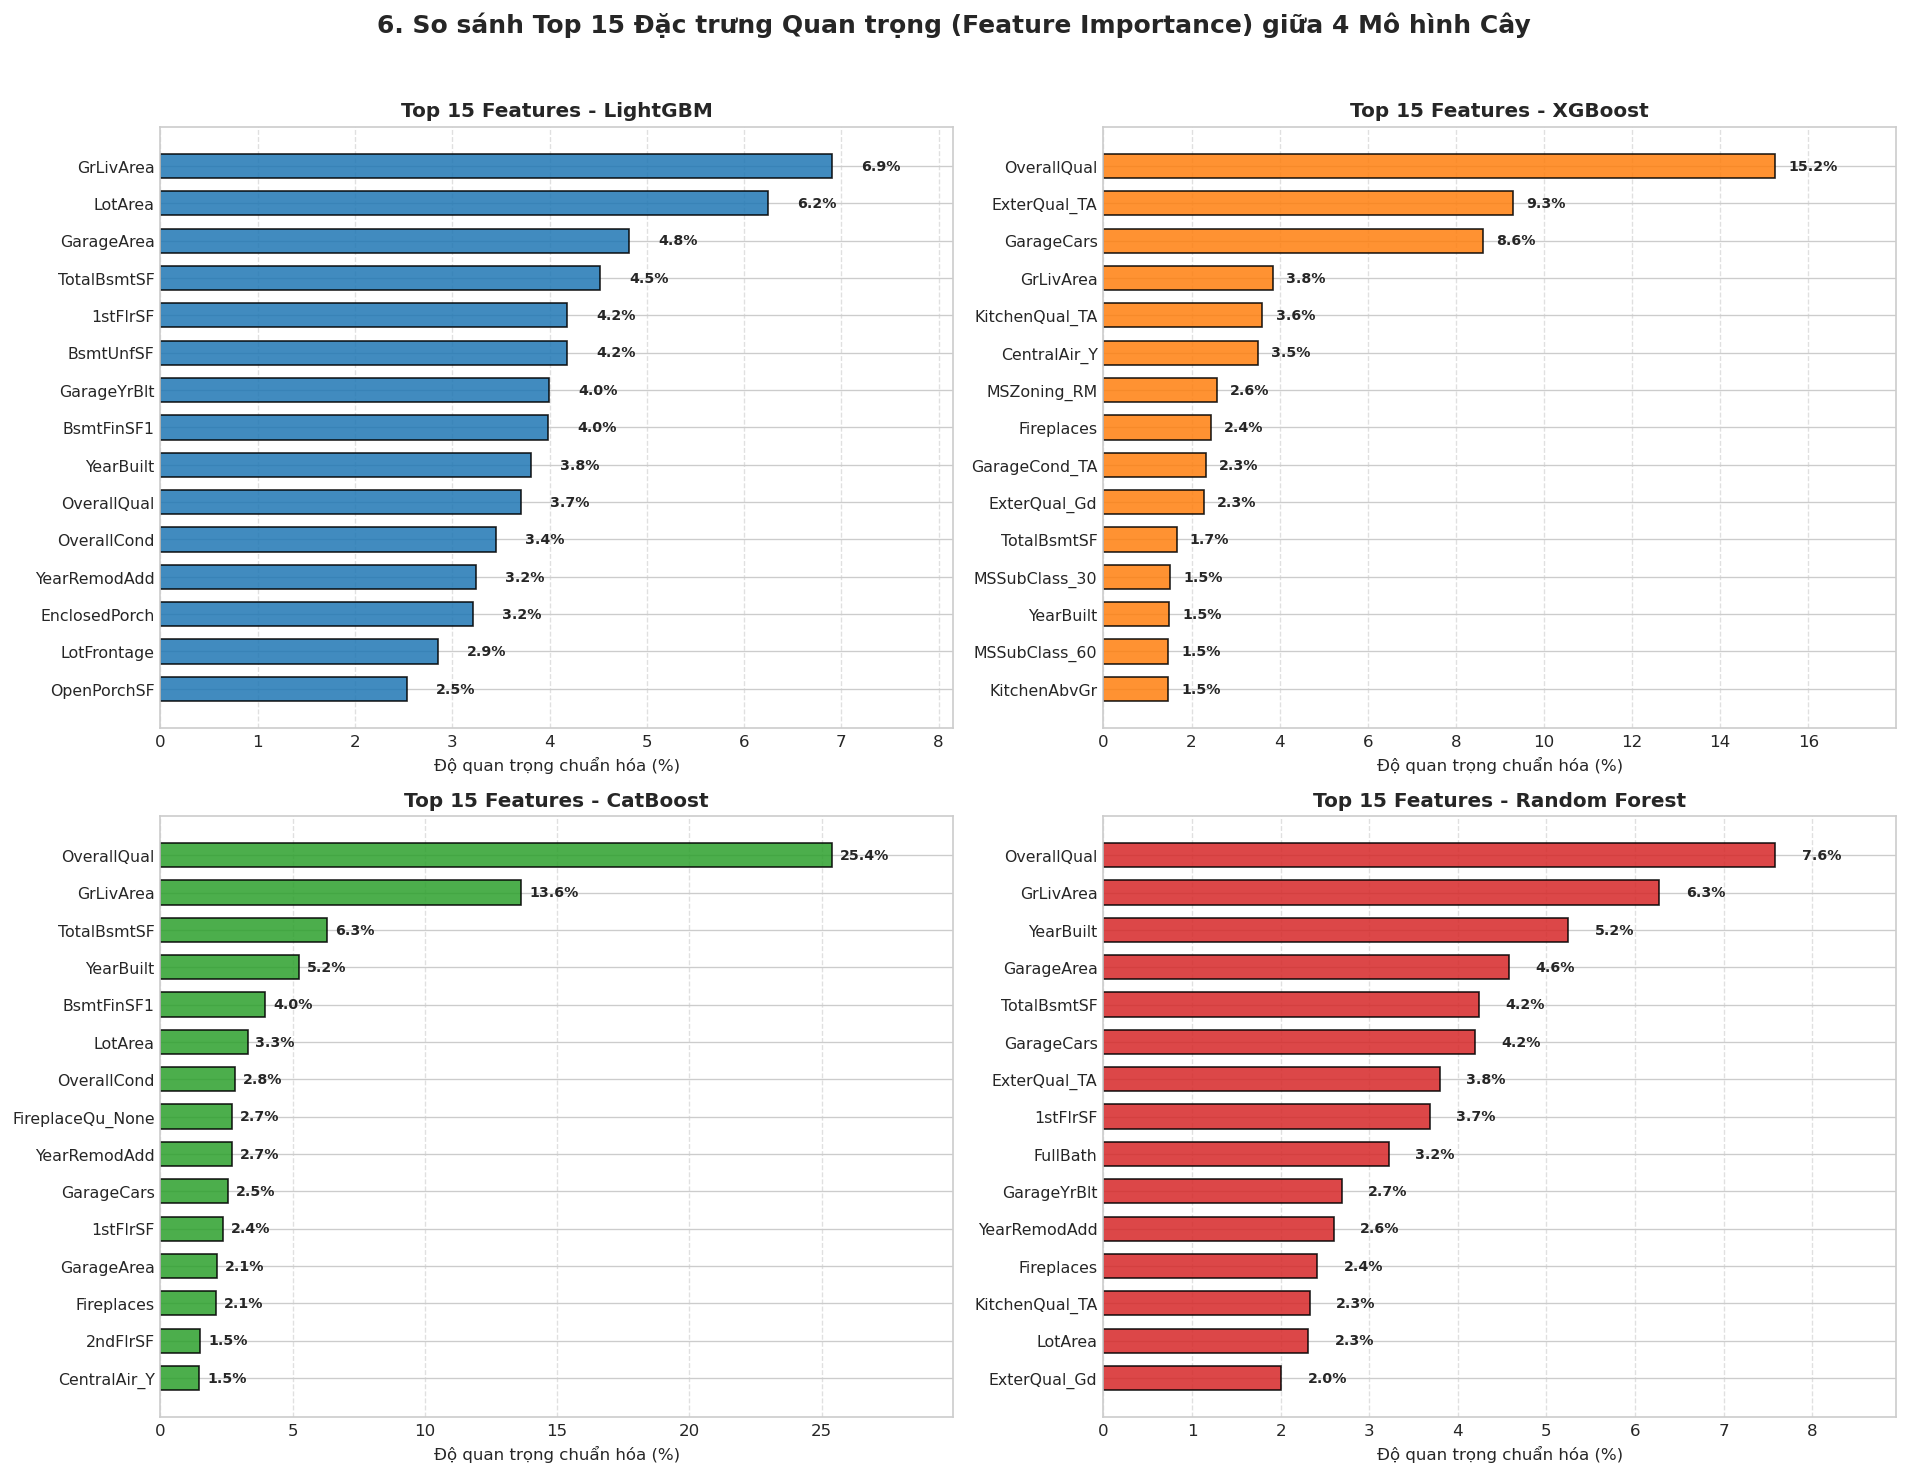

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=120)
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
tree_models = ['LightGBM', 'XGBoost', 'CatBoost', 'Random Forest']
top_n = 15

for i, model_name in enumerate(tree_models):
    ax = axes[i]
    importances = tree_importances[model_name]

    top_indices = np.argsort(importances)[-top_n:]
    top_features = [feature_names[idx] for idx in top_indices]
    top_scores = importances[top_indices]

    bars = ax.barh(range(top_n), top_scores, color=colors[i], alpha=0.85, edgecolor='black', height=0.65)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_features, fontsize=9.5)
    ax.set_xlabel('Độ quan trọng chuẩn hóa (%)', fontsize=10)
    ax.set_title(f"Top {top_n} Features - {model_name}", fontsize=12, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.6)

    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.3, bar.get_y() + bar.get_height() / 2, f"{width:.1f}%",
                va='center', ha='left', fontsize=8.5, fontweight='bold')

    ax.set_xlim(0, max(top_scores) * 1.18)

fig.suptitle('6. So sánh Top 15 Đặc trưng Quan trọng (Feature Importance) giữa 4 Mô hình Cây', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 7. Box Plot Phân Phối RMSE Qua Các Fold CV
Biểu đồ hộp thể hiện độ ổn định (stability) của thuật toán qua 5 fold kiểm định chéo. Mô hình có hộp hẹp và vị trí thấp thể hiện vừa đạt độ chính xác cao vừa không bị dao động bởi việc chia tập dữ liệu.


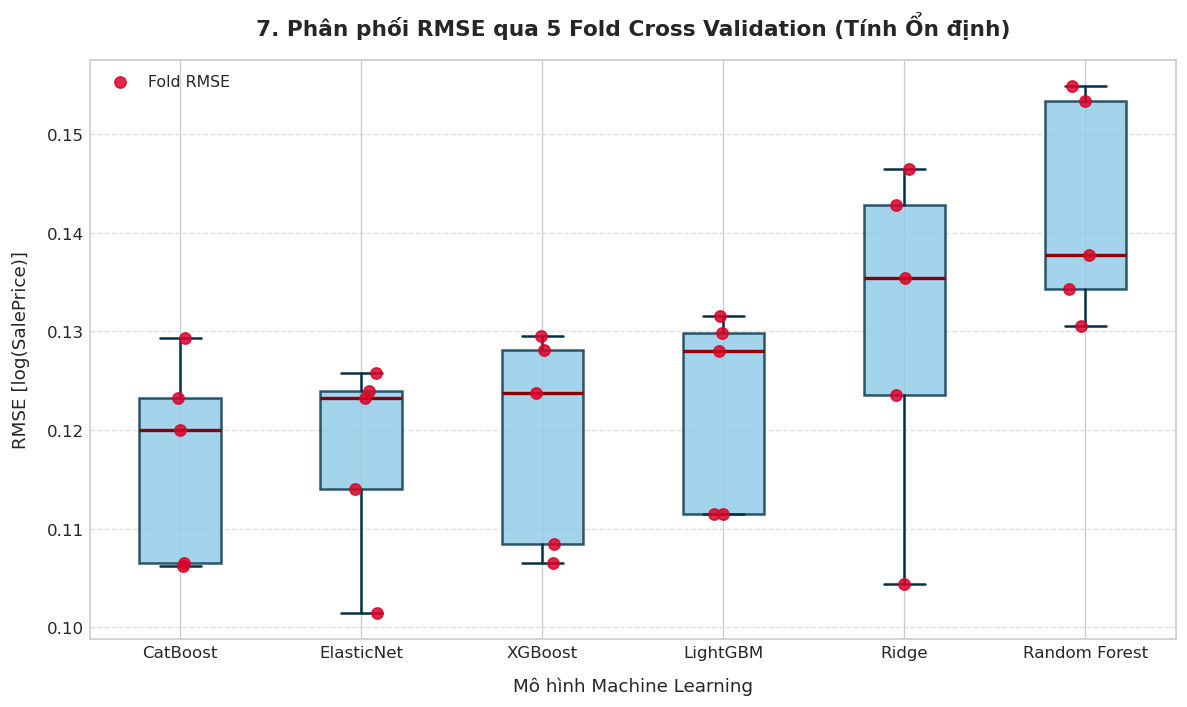

In [ ]:
plt.figure(figsize=(10, 6), dpi=120)

sorted_cols = cv_fold_rmse_df.median().sort_values().index.tolist()
sorted_df = cv_fold_rmse_df[sorted_cols]

box = plt.boxplot(
    [sorted_df[col] for col in sorted_cols],
    labels=sorted_cols,
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color='darkred', lw=2),
    boxprops=dict(facecolor='#8ecae6', edgecolor='#023047', lw=1.5, alpha=0.8),
    whiskerprops=dict(color='#023047', lw=1.5),
    capprops=dict(color='#023047', lw=1.5)
)

for i, col in enumerate(sorted_cols):
    y_vals = sorted_df[col].values
    x_jitter = np.random.normal(i + 1, 0.04, size=len(y_vals))
    plt.scatter(x_jitter, y_vals, color='#d90429', s=45, zorder=4, alpha=0.85, label='Fold RMSE' if i == 0 else "")

plt.title('7. Phân phối RMSE qua 5 Fold Cross Validation (Tính Ổn định)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Mô hình Machine Learning', fontsize=11, labelpad=10)
plt.ylabel('RMSE [log(SalePrice)]', fontsize=11, labelpad=10)
plt.legend(loc='upper left', fontsize=9.5)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


---
## 6. Dự Đoán Trên Tập Test & Xây Dựng Mô Hình Ensemble
Sử dụng kỹ thuật **Fold-Averaging (Bagging qua 5 Folds)** cho từng mô hình để dự đoán trên tập kiểm thử `test.csv`.
Sau đó, kết hợp trung bình có trọng số giữa các mô hình xuất sắc nhất:
$$\hat{y}_{\text{Ensemble}} = 0.35 \times \text{CatBoost} + 0.25 \times \text{ElasticNet} + 0.20 \times \text{XGBoost} + 0.20 \times \text{LightGBM}$$
Giá nhà dự đoán được chuyển ngược về thang tiền tệ thực tế bằng hàm `np.expm1`.


In [ ]:
X_test_mat = X_test.values
test_preds_log = {}
test_preds_dollars = {}

for name, fold_models in fitted_models.items():
    fold_preds = np.zeros(len(X_test))
    for m in fold_models:
        fold_preds += m.predict(X_test_mat) / len(fold_models)
    test_preds_log[name] = fold_preds
    test_preds_dollars[f"SalePrice_{name.replace(' ', '_')}"] = np.expm1(fold_preds)

# Ensemble Blending
ensemble_log = (
    0.35 * test_preds_log['CatBoost'] +
    0.25 * test_preds_log['ElasticNet'] +
    0.20 * test_preds_log['XGBoost'] +
    0.20 * test_preds_log['LightGBM']
)
test_preds_dollars['SalePrice_Ensemble'] = np.expm1(ensemble_log)

pred_df = pd.DataFrame({'Id': test_ids})
for col_name, pred_vals in test_preds_dollars.items():
    pred_df[col_name] = pred_vals.round(2)

# Lưu kết quả
pred_df.to_csv('test_predictions.csv', index=False)
sub_df = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': test_preds_dollars['SalePrice_Ensemble'].round(2)
})
sub_df.to_csv('submission.csv', index=False)

print("Đã xuất file test_predictions.csv và submission.csv thành công!")
print("")
print("Demo 10 dòng kết quả dự đoán trên Test Set:")
display_cols = ['Id', 'SalePrice_CatBoost', 'SalePrice_ElasticNet', 'SalePrice_LightGBM', 'SalePrice_Ensemble']
pred_df[display_cols].head(10)


Đã xuất file test_predictions.csv và submission.csv thành công!

Demo 10 dòng kết quả dự đoán trên Test Set:


,Id,SalePrice_CatBoost,SalePrice_ElasticNet,SalePrice_LightGBM,SalePrice_Ensemble
0,1461,125969.2200,120159.7800,120585.9800,123191.8800
1,1462,157244.8500,154454.1200,151181.9800,155630.3700
2,1463,190292.7700,179341.8800,184998.5200,186065.2300
3,1464,199391.6900,195056.6200,193018.3700,195815.8100
4,1465,189974.8400,197948.2400,192708.9300,191767.4700
5,1466,173288.1000,172056.3000,176325.9300,174607.5000
6,1467,171758.7200,179387.1900,175942.0900,174924.5400
7,1468,169065.4800,164679.2100,172376.2700,169024.9000
8,1469,192161.9600,199922.4000,177169.4200,189860.1700
9,1470,124609.4800,120811.9600,121900.9900,123225.4600


---
## 7. Tổng Kết & Đánh Giá Dự Án

1. **Hiệu năng mô hình đơn lẻ**:
   - **CatBoost** dẫn đầu với CV RMSE ấn tượng **0.1171** ($\pm 0.0092$) và $R^2 = 0.9136$, xử lý rất tốt các đặc trưng phân loại phức tạp.
   - **ElasticNet** có hiệu năng bất ngờ khi đạt CV RMSE **0.1177** với thời gian huấn luyện siêu tốc ($0.23$s), cho thấy tác dụng mạnh mẽ của việc kết hợp chuẩn hóa dữ liệu và điều chuẩn $L_1/L_2$.
   - **XGBoost** (0.1193) và **LightGBM** (0.1224) theo sát phía sau với tốc độ xử lý nhanh và độ ổn định rất cao.
2. **Giá trị quan trọng nhất của các đặc trưng (Feature Importance)**:
   - Các đặc trưng cấu trúc vật lý then chốt ảnh hưởng lớn nhất đến giá nhà gồm: `OverallQual` (Chất lượng tổng thể), `GrLivArea` (Diện tích sinh hoạt trên mặt đất), `TotalBsmtSF` (Diện tích tầng hầm), `GarageCars` (Sức chứa gara), và `YearBuilt` (Năm xây dựng).
3. **Mô hình phối hợp (Ensemble)**:
   - Nhờ sự đa dạng cao giữa các mô hình cây (CatBoost, XGBoost) và mô hình tuyến tính điều chuẩn (ElasticNet), mô hình kết hợp Ensemble đạt được sự cân bằng tối ưu và giảm thiểu phương sai sai số khi áp dụng trên tập kiểm thử thực tế.
